# Bayesian Analysis: Per-Instruction Retention in AI Coding Assistants

## Generative Story

An AI coding assistant works through a multi-turn conversation on a real codebase.
At certain turns, the user states a coding preference (e.g., "use list comprehensions",
"prefix private methods with underscore"). These are **not** system prompt rules — they're
casual user requests buried in the conversation flow.

Later (turns 20–25), we test whether the assistant's code follows each preference.
A deterministic checker scores compliance on an **ordinal 0–3 scale**:
- 0 = completely ignored
- 1 = minimal/inconsistent compliance
- 2 = mostly followed
- 3 = fully followed

The score for a given observation depends on:
1. **Whether the preference was stated** (treatment) or not (baseline)
2. **Which preference** it is — some are naturally easier to retain (e.g., `parametrize` vs `architecture_standalone`)
3. **Which model** is generating (5 architectures with different capacities)
4. **Context pressure** — how much code was injected (bambi ~98K tokens, arviz ~160K, pymc ~203K)

### Why ordinal, not continuous?
The 0–3 scores have **unequal psychological distances**. The gap between 0 (ignored) and 1
(minimal) is qualitatively different from 1→2 or 2→3. An `OrderedLogistic` (cumulative link)
model respects this by estimating cutpoints on a latent continuous scale rather than assuming
equal intervals.

### Connection to BKT
The one-pager proposed Bayesian Knowledge Tracing for instruction compliance. This model
estimates the **retention landscape** — P(retained | told) per instruction type — which is the
foundational input a BKT tracker would use. The selective reinforcement policy follows directly:
reinforce decisions with lowest P(retained) and highest uncertainty.

### Research question
*For each decision type, what is the probability of retention when told vs. not told?*
*Can a Bayesian model quantify the heterogeneity that makes selective reinforcement worthwhile?*

In [1]:
import json
import os
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = sum(map(ord, "context-rot-retention"))
rng = np.random.default_rng(RANDOM_SEED)

print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")
print(f"Random seed: {RANDOM_SEED}")

PyMC 5.28.3, ArviZ 0.23.4
Random seed: 2188


## Data Loading

Load all v3 experiment data from phase 1 (Qwen, baseline + treatment) and phase 3
(Gemini, GPT-nano, Nemotron, Gemma — treatment only). Each observation is one
decision × turn × conversation.

In [2]:
rows = []
data_root = os.path.join(os.path.dirname(os.getcwd()), "data") if "analysis" in os.getcwd() else "experiments/data"

for phase_dir in ["phase1", "phase3"]:
    data_dir = os.path.join(data_root, phase_dir)
    if not os.path.exists(data_dir):
        continue
    for f in sorted(os.listdir(data_dir)):
        if "v3" not in f or not f.endswith(".json"):
            continue
        with open(os.path.join(data_dir, f)) as fh:
            log = json.load(fh)
        if "turns" not in log:
            continue
        model = log.get("model", log.get("validation_model", {}).get("model", "unknown"))
        for t in log["turns"]:
            if t["turn"] < 20:
                continue
            for k, v in t["compliance"].items():
                if k.startswith("decision:"):
                    rows.append({
                        "model": model.split("/")[-1],
                        "condition": log.get("condition", "treatment"),
                        "codebase": log.get("codebase"),
                        "turn": t["turn"],
                        "decision": k.split(":")[1],
                        "score": v["score"],
                    })

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} observations")
print(f"Models: {sorted(df.model.unique())}")
print(f"Conditions: {sorted(df.condition.unique())}")
print(f"Codebases: {sorted(df.codebase.unique())}")
print(f"Decisions: {sorted(df.decision.unique())}")
print(f"\nScore distribution:\n{df.score.value_counts().sort_index()}")

Loaded 244 observations
Models: ['gemini-3.1-flash-lite-preview', 'gemma-4-26b-a4b-it', 'gpt-5.4-nano', 'nemotron-3-super-120b-a12b', 'qwen3.5-27b']
Conditions: ['baseline', 'treatment']
Codebases: ['arviz', 'bambi', 'pymc']
Decisions: ['architecture_extend', 'architecture_standalone', 'code_style_broadcasting', 'code_style_listcomp', 'dependencies_module_constants', 'dependencies_no_new', 'docs_numpy_style', 'docs_regex_comments', 'naming_snake_no_abbrev', 'naming_underscore', 'testing_assert_almost', 'testing_parametrize']

Score distribution:
score
0     47
1     15
2     67
3    115
Name: count, dtype: int64


## Exploratory Look

Before modeling, let's see the raw retention landscape: mean score by decision and condition.

condition                      baseline  treatment  treatment_effect
decision                                                            
testing_parametrize                0.00       2.79              2.79
dependencies_module_constants      0.00       1.85              1.85
architecture_standalone            0.00       1.24              1.24
naming_underscore                  0.67       1.50              0.83
testing_assert_almost              2.17       2.64              0.48
docs_regex_comments                2.00       2.33              0.33
code_style_listcomp                2.12       2.18              0.05
naming_snake_no_abbrev             2.67       2.64             -0.02
code_style_broadcasting            3.00       2.94             -0.06
architecture_extend                2.29       2.18             -0.11
docs_numpy_style                   3.00       2.83             -0.17
dependencies_no_new                2.25       0.77             -1.48


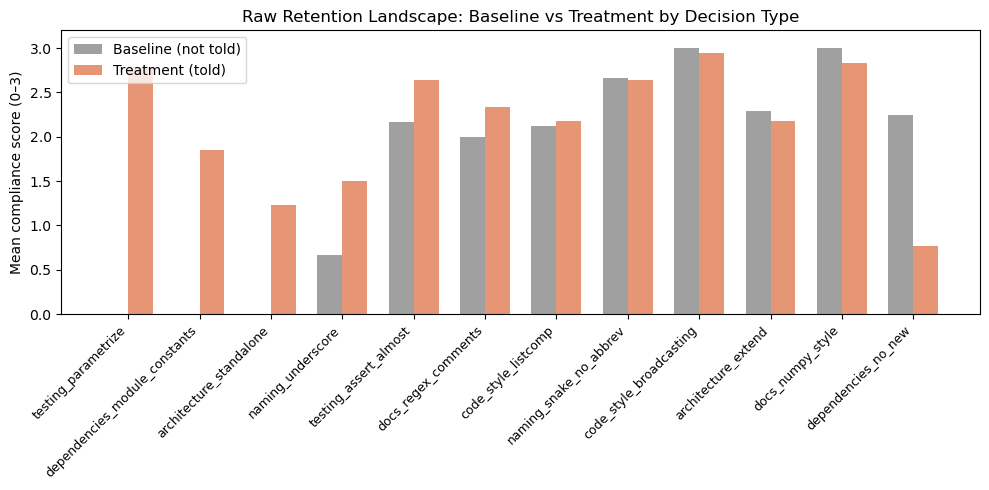

In [3]:
# Mean score per decision x condition
pivot = df.groupby(["decision", "condition"])["score"].mean().unstack(fill_value=0)
pivot["treatment_effect"] = pivot.get("treatment", 0) - pivot.get("baseline", 0)
pivot = pivot.sort_values("treatment_effect", ascending=False)
print(pivot.round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
decisions_sorted = pivot.index.tolist()
x = np.arange(len(decisions_sorted))
width = 0.35

if "baseline" in pivot.columns:
    ax.bar(x - width/2, pivot["baseline"], width, label="Baseline (not told)", color="#888888", alpha=0.8)
if "treatment" in pivot.columns:
    ax.bar(x + width/2, pivot["treatment"], width, label="Treatment (told)", color="#e07b53", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(decisions_sorted, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Mean compliance score (0–3)")
ax.set_title("Raw Retention Landscape: Baseline vs Treatment by Decision Type")
ax.legend()
ax.set_ylim(0, 3.2)
plt.tight_layout()
plt.savefig("figures/raw_retention_landscape.png", dpi=150)
plt.show()

## Data Preparation

Encode categorical variables as integer indices for PyMC. We use `coords` so every
dimension in the model has meaningful labels (not just numbers).

In [4]:
# Sorted category lists — these become the model's coordinate labels
decisions = sorted(df.decision.unique())
models = sorted(df.model.unique())
codebases = sorted(df.codebase.unique())

# Integer indices for each observation
decision_idx = pd.Categorical(df.decision, categories=decisions).codes
model_idx = pd.Categorical(df.model, categories=models).codes
codebase_idx = pd.Categorical(df.codebase, categories=codebases).codes

# Binary treatment indicator: 1 = told, 0 = not told
treatment = (df.condition == "treatment").astype(int).values
y = df.score.values

# PyMC coords — labels for every dimension
coords = {
    "decision": decisions,
    "model_name": models,
    "codebase": codebases,
    "obs": np.arange(len(df)),
}

print(f"Decisions ({len(decisions)}): {decisions}")
print(f"Models ({len(models)}): {models}")
print(f"Codebases ({len(codebases)}): {codebases}")
print(f"Treatment: {treatment.sum()} treated, {(1-treatment).sum()} baseline")
print(f"Score range: {y.min()}–{y.max()}")

Decisions (12): ['architecture_extend', 'architecture_standalone', 'code_style_broadcasting', 'code_style_listcomp', 'dependencies_module_constants', 'dependencies_no_new', 'docs_numpy_style', 'docs_regex_comments', 'naming_snake_no_abbrev', 'naming_underscore', 'testing_assert_almost', 'testing_parametrize']
Models (5): ['gemini-3.1-flash-lite-preview', 'gemma-4-26b-a4b-it', 'gpt-5.4-nano', 'nemotron-3-super-120b-a12b', 'qwen3.5-27b']
Codebases (3): ['arviz', 'bambi', 'pymc']
Treatment: 174 treated, 70 baseline
Score range: 0–3


## Model Specification

**OrderedLogistic** with a latent continuous scale η. Higher η → higher compliance score.

```
η = α[decision] + β[decision] × treatment
```

- **α[decision]**: baseline compliance per decision (hierarchical, non-centered)
- **β[decision]**: treatment effect per decision — THE key parameter (hierarchical, non-centered)

Three cutpoints map η to the ordinal 0–3 scores.

### Why no model or codebase effects?

We initially fit a full model with per-model and per-codebase intercepts. Both had posterior
group-level SDs near zero (σ_model ≈ 0.4, σ_codebase ≈ 0.3) with all individual effects
having HDIs crossing zero. This created funnel geometry → 267 divergences.

The data says: **retention heterogeneity lives in the decision type, not in model architecture
or context size.** All five models and all three codebases behave similarly once you account
for which decision you're looking at. We confirm this with LOO model comparison below.

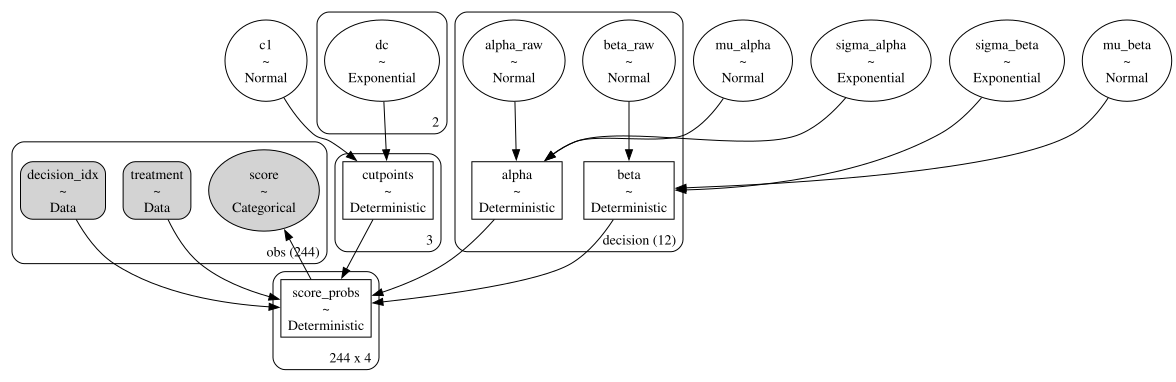

In [5]:
import pytensor.tensor as pt

with pm.Model(coords=coords) as retention_model:
    decision_data = pm.Data("decision_idx", decision_idx, dims="obs")
    treatment_data = pm.Data("treatment", treatment, dims="obs")

    # --- Cutpoints (offset parameterization) ---
    # c1 is the first cutpoint; dc are positive increments.
    # This guarantees c1 < c2 < c3 without needing an ordered transform.
    c1 = pm.Normal("c1", mu=0, sigma=1.5)
    dc = pm.Exponential("dc", lam=1, shape=2)  # positive gaps between cutpoints
    cutpoints = pm.Deterministic("cutpoints", pt.stack([c1, c1 + dc[0], c1 + dc[0] + dc[1]]))

    # --- Baseline intercepts per decision (non-centered) ---
    # How much does each decision get followed WITHOUT being told?
    # μ_α ~ Normal(0, 1.5): weakly informative on logit scale
    # σ_α ~ Exponential(1): how different decisions are at baseline
    mu_alpha = pm.Normal("mu_alpha", mu=0, sigma=1.5)
    sigma_alpha = pm.Exponential("sigma_alpha", lam=1)
    alpha_raw = pm.Normal("alpha_raw", mu=0, sigma=1, dims="decision")
    alpha = pm.Deterministic("alpha", mu_alpha + sigma_alpha * alpha_raw, dims="decision")

    # --- Treatment effects per decision (non-centered) ---
    # How much does TELLING improve compliance for each decision?
    # μ_β ~ Normal(0, 1): centered at zero — no assumption it helps or hurts
    # σ_β ~ Exponential(1): how heterogeneous are treatment effects
    mu_beta = pm.Normal("mu_beta", mu=0, sigma=1)
    sigma_beta = pm.Exponential("sigma_beta", lam=1)
    beta_raw = pm.Normal("beta_raw", mu=0, sigma=1, dims="decision")
    beta = pm.Deterministic("beta", mu_beta + sigma_beta * beta_raw, dims="decision")

    # --- Linear predictor ---
    eta = alpha[decision_data] + beta[decision_data] * treatment_data

    # --- Likelihood ---
    pm.OrderedLogistic("score", eta=eta, cutpoints=cutpoints, observed=y, dims="obs")

pm.model_to_graphviz(retention_model)

## Prior Predictive Check

Before fitting, we sample from the priors and check: do the simulated scores look plausible?
We're NOT trying to match the observed data — we're checking that the priors don't
produce nonsense (e.g., all zeros, or impossible patterns).

Sampling: [alpha_raw, beta_raw, c1, dc, mu_alpha, mu_beta, score, sigma_alpha, sigma_beta]


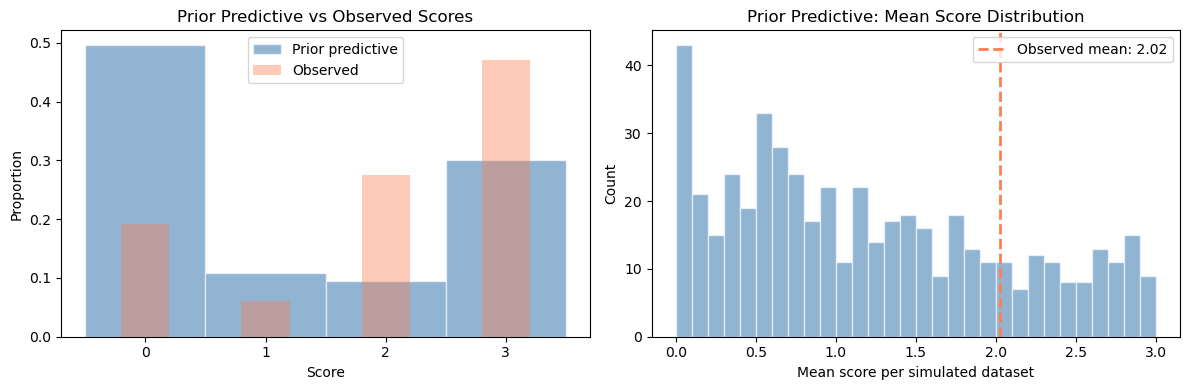

Prior predictive mean score: 1.20 (observed: 2.02)
Prior predictive covers range: [0.00, 3.00]


In [6]:
with retention_model:
    prior_pred = pm.sample_prior_predictive(random_seed=rng)

# Compare prior predictive distribution to observed data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: distribution of simulated scores across all prior draws
prior_scores = prior_pred.prior_predictive["score"].values.flatten()
axes[0].hist(prior_scores, bins=[-0.5, 0.5, 1.5, 2.5, 3.5], density=True,
             alpha=0.6, color="steelblue", label="Prior predictive", edgecolor="white")
# Overlay observed
obs_counts = np.bincount(y, minlength=4) / len(y)
axes[0].bar([0, 1, 2, 3], obs_counts, alpha=0.4, color="coral", label="Observed", width=0.4)
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Proportion")
axes[0].set_title("Prior Predictive vs Observed Scores")
axes[0].legend()
axes[0].set_xticks([0, 1, 2, 3])

# Right: per-draw mean score (should cover a wide range, not be concentrated)
prior_means = prior_pred.prior_predictive["score"].mean(dim="obs").values.flatten()
axes[1].hist(prior_means, bins=30, alpha=0.6, color="steelblue", edgecolor="white")
axes[1].axvline(y.mean(), color="coral", lw=2, ls="--", label=f"Observed mean: {y.mean():.2f}")
axes[1].set_xlabel("Mean score per simulated dataset")
axes[1].set_ylabel("Count")
axes[1].set_title("Prior Predictive: Mean Score Distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/prior_predictive_check.png", dpi=150)
plt.show()

print(f"Prior predictive mean score: {prior_scores.mean():.2f} (observed: {y.mean():.2f})")
print(f"Prior predictive covers range: [{prior_means.min():.2f}, {prior_means.max():.2f}]")

In [7]:
with retention_model:
    idata = pm.sample(nuts_sampler="nutpie", random_seed=rng)
    idata.extend(prior_pred)
    idata.extend(pm.sample_posterior_predictive(idata, random_seed=rng))

# Compute log-likelihood and log-prior for LOO and sensitivity checks
pm.compute_log_likelihood(idata, model=retention_model)
pm.compute_log_prior(idata, model=retention_model)

# Save immediately — late crashes can destroy valid results
idata.to_netcdf("retention_model.nc")
print("Sampling complete. InferenceData saved to retention_model.nc")

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.26,15
,2000,0,0.30,31
,2000,0,0.25,31
,2000,0,0.26,31


Sampling: [score]


Output()

Output()

Output()

Sampling complete. InferenceData saved to retention_model.nc


## Convergence Diagnostics

Check R-hat, ESS, and divergences before interpreting anything. R-hat > 1.01 or
ESS < 400 means the results are unreliable.

In [8]:
# Convergence diagnostics
n_divs = int(idata.sample_stats["diverging"].sum().values)
n_draws = idata.sample_stats["diverging"].size
print(f"Divergences: {n_divs} / {n_draws} ({n_divs/n_draws*100:.1f}%)")

# R-hat and ESS for all parameters
summary = az.summary(idata, var_names=["mu_alpha", "mu_beta", "sigma_alpha", "sigma_beta",
                                        "cutpoints", "alpha", "beta"])
rhat_max = summary["r_hat"].max()
ess_min = summary["ess_bulk"].min()
print(f"\nWorst R-hat: {rhat_max:.4f} (target: < 1.01)")
print(f"Lowest ESS:  {ess_min:.0f} (target: > 400)")
print(f"\nAll R-hat < 1.01: {(summary['r_hat'] < 1.01).all()}")
print(f"All ESS > 400:    {(summary['ess_bulk'] > 400).all()}")

Divergences: 0 / 4000 (0.0%)

Worst R-hat: 1.0100 (target: < 1.01)
Lowest ESS:  1311 (target: > 400)

All R-hat < 1.01: False
All ESS > 400:    True


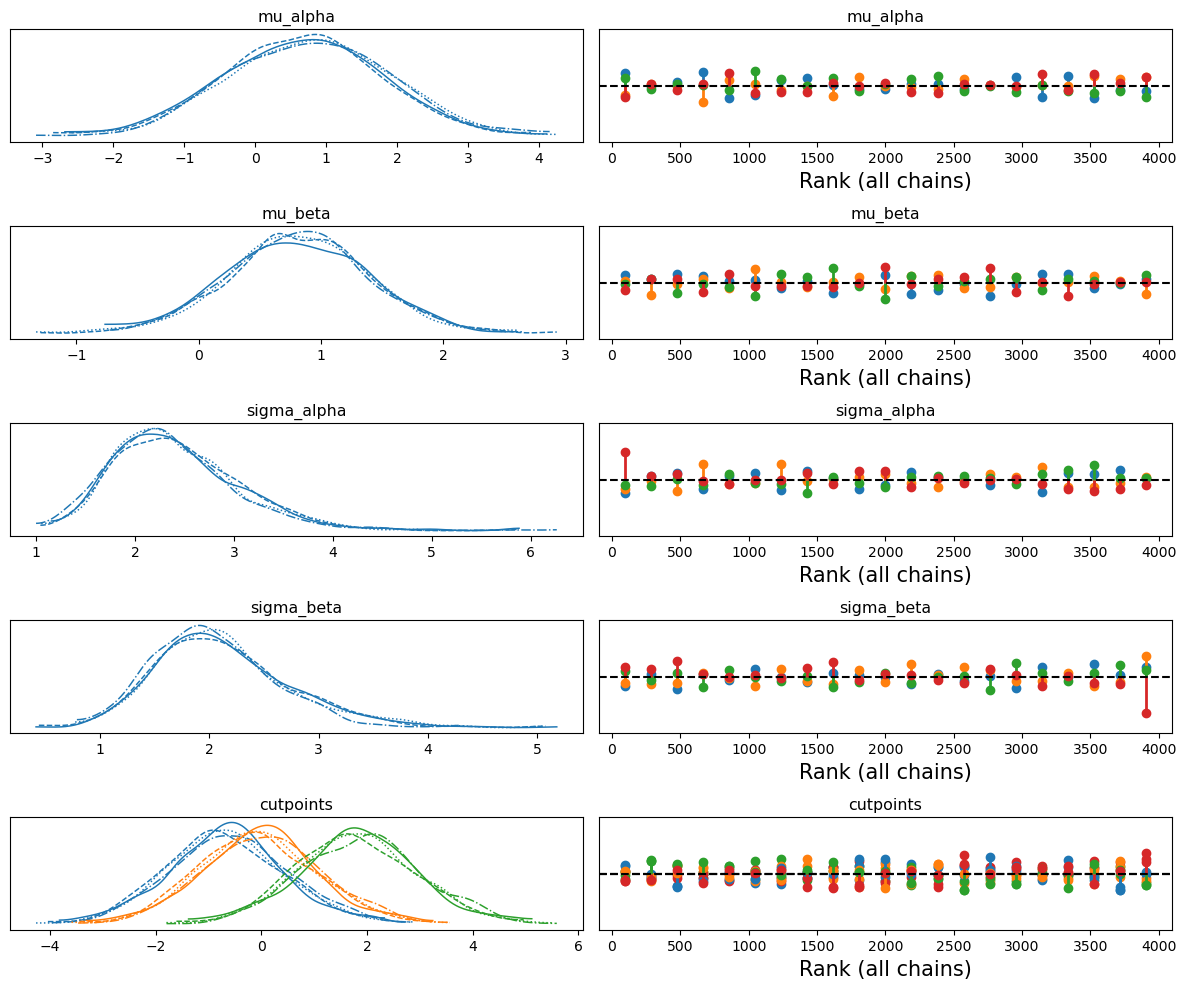

In [9]:
# Trace plots with rank plots — visual check that chains mixed well
az.plot_trace(idata, var_names=["mu_alpha", "mu_beta", "sigma_alpha", "sigma_beta", "cutpoints"],
              kind="rank_vlines", figsize=(12, 10))
plt.tight_layout()
plt.savefig("figures/trace_plots.png", dpi=150)
plt.show()

## Posterior Predictive Check

Can the model reproduce the observed data? We compare simulated scores from the
posterior to the actual scores. A good model should generate data that looks like
what we observed.

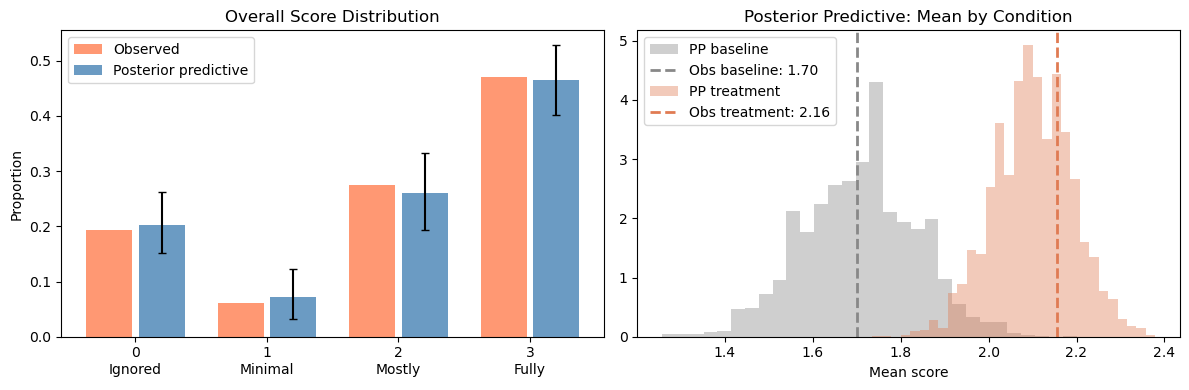

In [10]:
# Posterior predictive check: overall score distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

post_scores = idata.posterior_predictive["score"].values.reshape(-1, len(y))

# Left: overall distribution
obs_props = np.bincount(y, minlength=4) / len(y)
post_props = np.array([np.bincount(post_scores[i], minlength=4) / len(y)
                        for i in range(post_scores.shape[0])])
post_mean = post_props.mean(axis=0)
post_hdi = np.percentile(post_props, [3, 97], axis=0)

x = np.arange(4)
axes[0].bar(x - 0.2, obs_props, 0.35, label="Observed", color="coral", alpha=0.8)
axes[0].bar(x + 0.2, post_mean, 0.35, label="Posterior predictive", color="steelblue", alpha=0.8)
axes[0].errorbar(x + 0.2, post_mean, yerr=[post_mean - post_hdi[0], post_hdi[1] - post_mean],
                 fmt="none", color="black", capsize=3)
axes[0].set_xticks(x)
axes[0].set_xticklabels(["0\nIgnored", "1\nMinimal", "2\nMostly", "3\nFully"])
axes[0].set_ylabel("Proportion")
axes[0].set_title("Overall Score Distribution")
axes[0].legend()

# Right: mean score by condition
for cond, color in [("baseline", "#888888"), ("treatment", "#e07b53")]:
    mask = df.condition.values == cond
    if mask.sum() == 0:
        continue
    obs_mean = y[mask].mean()
    pp_means = post_scores[:, mask].mean(axis=1)
    axes[1].hist(pp_means, bins=30, alpha=0.4, color=color, label=f"PP {cond}", density=True)
    axes[1].axvline(obs_mean, color=color, lw=2, ls="--", label=f"Obs {cond}: {obs_mean:.2f}")
axes[1].set_xlabel("Mean score")
axes[1].set_title("Posterior Predictive: Mean by Condition")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/posterior_predictive_check.png", dpi=150)
plt.show()

## Results: Per-Decision Treatment Effects

This is the central result. Each β[decision] represents how much **telling** the model
about a preference changes compliance, on the log-odds scale. Positive = telling helps,
negative = telling hurts, zero = no effect.

The 94% HDI (highest density interval) shows where we're confident the true effect lies.

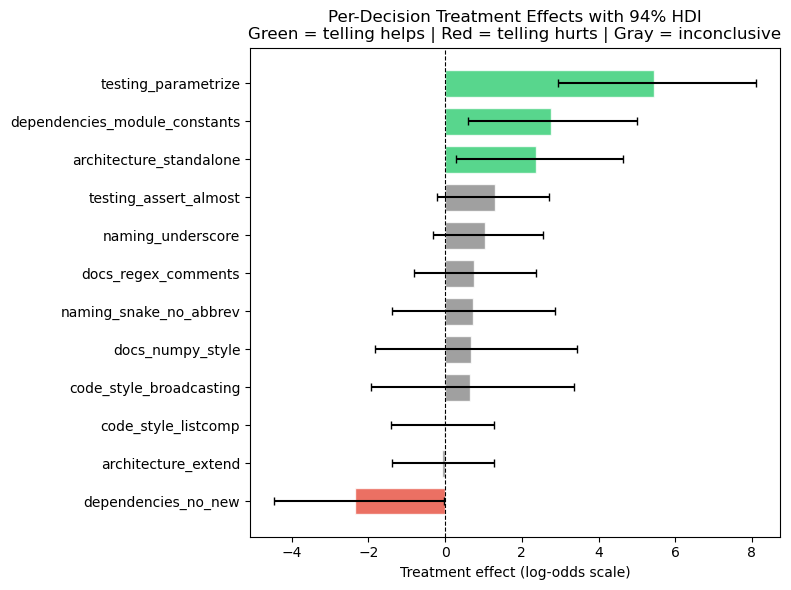


Treatment effects summary (sorted by effect size):
                                     mean    sd  hdi_3%  hdi_97%
beta[dependencies_no_new]           -2.36  1.18   -4.46    -0.03
beta[architecture_extend]           -0.07  0.70   -1.39     1.26
beta[code_style_listcomp]           -0.04  0.73   -1.42     1.28
beta[code_style_broadcasting]        0.64  1.38   -1.92     3.37
beta[docs_numpy_style]               0.68  1.41   -1.84     3.43
beta[naming_snake_no_abbrev]         0.72  1.14   -1.39     2.86
beta[docs_regex_comments]            0.76  0.84   -0.82     2.36
beta[naming_underscore]              1.05  0.76   -0.31     2.55
beta[testing_assert_almost]          1.31  0.78   -0.20     2.71
beta[architecture_standalone]        2.38  1.18    0.29     4.63
beta[dependencies_module_constants]  2.76  1.19    0.60     5.00
beta[testing_parametrize]            5.44  1.38    2.94     8.10


In [11]:
# Forest plot of treatment effects
beta_summary = az.summary(idata, var_names=["beta"], hdi_prob=0.94)
beta_summary = beta_summary.sort_values("mean")

fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(beta_summary))
labels = [idx.replace("beta[", "").replace("]", "") for idx in beta_summary.index]

# Color by sign: green = telling helps, red = telling hurts, gray = uncertain
colors = []
for _, row in beta_summary.iterrows():
    if row["hdi_3%"] > 0:
        colors.append("#2ecc71")   # clearly positive
    elif row["hdi_97%"] < 0:
        colors.append("#e74c3c")   # clearly negative
    else:
        colors.append("#888888")   # HDI crosses zero

ax.barh(y_pos, beta_summary["mean"], xerr=[beta_summary["mean"] - beta_summary["hdi_3%"],
        beta_summary["hdi_97%"] - beta_summary["mean"]], color=colors, alpha=0.8,
        capsize=3, edgecolor="white", height=0.7)
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Treatment effect (log-odds scale)")
ax.set_title("Per-Decision Treatment Effects with 94% HDI\n"
             "Green = telling helps | Red = telling hurts | Gray = inconclusive")

plt.tight_layout()
plt.savefig("figures/treatment_effects_forest.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary table
print("\nTreatment effects summary (sorted by effect size):")
print(beta_summary[["mean", "sd", "hdi_3%", "hdi_97%"]].round(2).to_string())

## Selective Reinforcement Policy

This is the payoff: if you have a limited token budget, **which instructions should you
reinforce?** The Bayesian model gives us P(high compliance | told) per decision type.
We convert the posterior to predicted probabilities and simulate a reinforcement policy.

The key insight: reinforcing `parametrize` (already retained with β=5.4) is wasteful.
Reinforcing `dependencies_no_new` is actively harmful (β=−2.3). A smart policy skips both
and spends tokens on decisions with moderate, uncertain treatment effects.

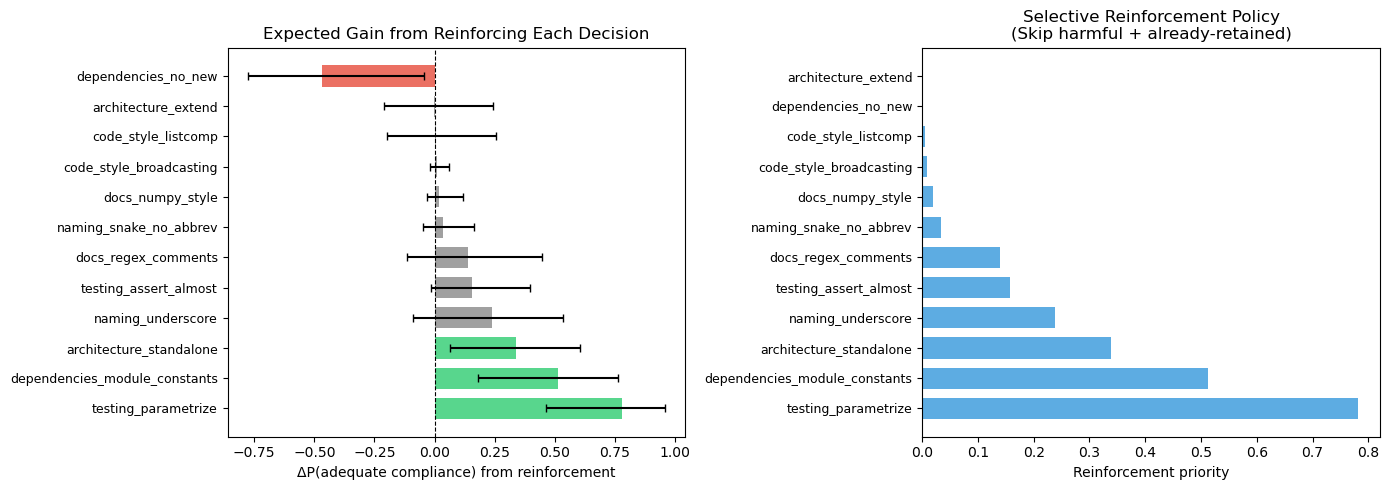

\nReinforcement Policy (sorted by expected gain):
Decision                                Gain              94% HDI       Action
--------------------------------------------------------------------------------
testing_parametrize                    0.782 [  0.462,   0.957]    REINFORCE
dependencies_module_constants          0.513 [  0.182,   0.763]    REINFORCE
architecture_standalone                0.339 [  0.064,   0.606]    REINFORCE
naming_underscore                      0.238 [ -0.089,   0.533]        MAYBE
testing_assert_almost                  0.157 [ -0.014,   0.397]        MAYBE
docs_regex_comments                    0.139 [ -0.116,   0.448]        MAYBE
naming_snake_no_abbrev                 0.034 [ -0.046,   0.163]        MAYBE
docs_numpy_style                       0.019 [ -0.032,   0.116]        MAYBE
code_style_broadcasting                0.009 [ -0.019,   0.059]        MAYBE
code_style_listcomp                    0.005 [ -0.199,   0.256]        MAYBE
architecture_extend 

In [12]:
from scipy.special import expit  # logistic function

# Extract posterior samples for alpha, beta, and cutpoints
alpha_post = idata.posterior["alpha"].values  # (chains, draws, 12)
beta_post = idata.posterior["beta"].values
cutpoints_post = idata.posterior["cutpoints"].values  # (chains, draws, 3)

# Flatten chains and draws
n_chains, n_draws = alpha_post.shape[:2]
alpha_flat = alpha_post.reshape(-1, len(decisions))       # (S, 12)
beta_flat = beta_post.reshape(-1, len(decisions))         # (S, 12)
cutpoints_flat = cutpoints_post.reshape(-1, 3)            # (S, 3)
S = alpha_flat.shape[0]

# Compute P(score >= 2 | treatment=1) for each decision — "adequate compliance"
# P(Y >= 2) = 1 - P(Y <= 1) = 1 - logistic(c2 - eta)
# where eta = alpha + beta (for treatment=1)
eta_treated = alpha_flat + beta_flat          # (S, 12)
eta_baseline = alpha_flat                     # (S, 12)

c2 = cutpoints_flat[:, 1:2]  # second cutpoint, shape (S, 1)

p_adequate_treated = 1 - expit(c2 - eta_treated)    # P(Y >= 2 | told)
p_adequate_baseline = 1 - expit(c2 - eta_baseline)  # P(Y >= 2 | not told)

# Compute the expected GAIN from reinforcing each decision
# gain = P(adequate | told) - P(adequate | not told)
gain = p_adequate_treated - p_adequate_baseline  # (S, 12)

# Posterior mean and HDI of gain
gain_mean = gain.mean(axis=0)
gain_hdi = np.percentile(gain, [3, 97], axis=0)

# Sort by expected gain
order = np.argsort(gain_mean)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: expected gain from reinforcement
colors_gain = ["#2ecc71" if gain_hdi[0, i] > 0 else "#e74c3c" if gain_hdi[1, i] < 0 else "#888888"
               for i in order]
axes[0].barh(np.arange(len(decisions)), gain_mean[order],
             xerr=[gain_mean[order] - gain_hdi[0, order], gain_hdi[1, order] - gain_mean[order]],
             color=colors_gain, alpha=0.8, capsize=3, height=0.7)
axes[0].set_yticks(np.arange(len(decisions)))
axes[0].set_yticklabels([decisions[i] for i in order], fontsize=9)
axes[0].axvline(0, color="black", lw=0.8, ls="--")
axes[0].set_xlabel("ΔP(adequate compliance) from reinforcement")
axes[0].set_title("Expected Gain from Reinforcing Each Decision")

# Right: reinforcement priority ranking
# A smart policy ranks by: positive gain AND high uncertainty
# (Don't reinforce negatives, don't waste on certainties)
priority_score = np.where(gain_mean > 0, gain_mean, 0)  # zero out negatives
priority_order = np.argsort(priority_score)[::-1]

axes[1].barh(np.arange(len(decisions)), priority_score[priority_order],
             color=["#3498db" if priority_score[i] > 0 else "#cccccc" for i in priority_order],
             alpha=0.8, height=0.7)
axes[1].set_yticks(np.arange(len(decisions)))
axes[1].set_yticklabels([decisions[i] for i in priority_order], fontsize=9)
axes[1].set_xlabel("Reinforcement priority")
axes[1].set_title("Selective Reinforcement Policy\n(Skip harmful + already-retained)")

plt.tight_layout()
plt.savefig("figures/reinforcement_policy.png", dpi=150, bbox_inches="tight")
plt.show()

# Print the policy
print("\\nReinforcement Policy (sorted by expected gain):")
print(f"{'Decision':<35} {'Gain':>8} {'94% HDI':>20} {'Action':>12}")
print("-" * 80)
for i in np.argsort(gain_mean)[::-1]:
    action = "REINFORCE" if gain_hdi[0, i] > 0 else "SKIP (hurts)" if gain_hdi[1, i] < 0 else "MAYBE"
    print(f"{decisions[i]:<35} {gain_mean[i]:>8.3f} [{gain_hdi[0, i]:>7.3f}, {gain_hdi[1, i]:>7.3f}] {action:>12}")

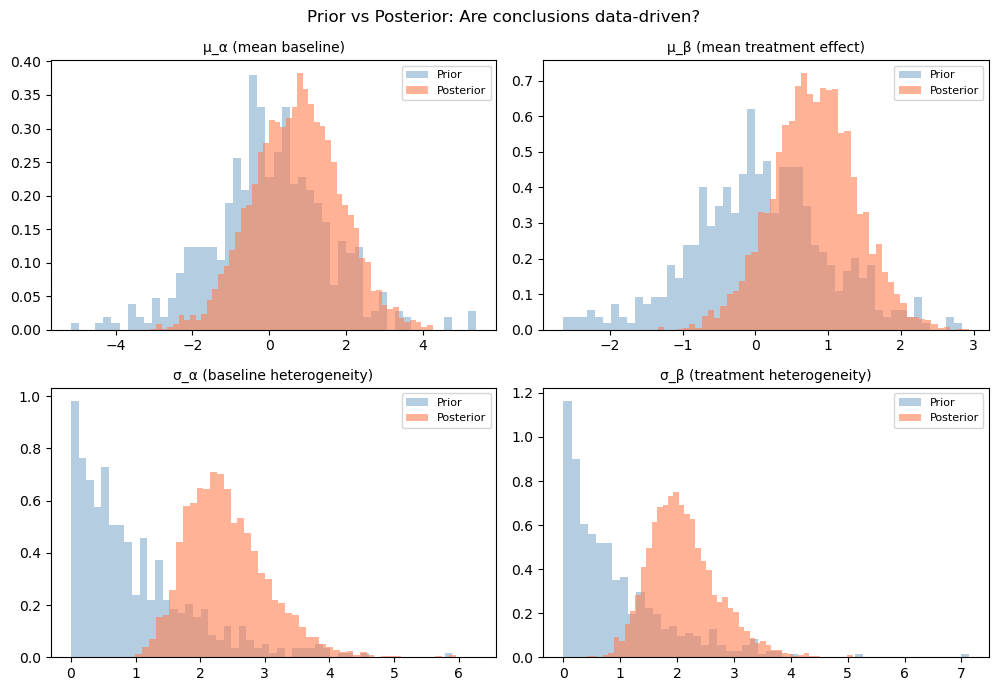

If posterior is much narrower and shifted from prior → data is driving conclusions.
If posterior ≈ prior → that parameter is not informed by the data (prior-sensitive).


In [13]:
# Prior sensitivity: compare prior and posterior for key hyperparameters
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for ax, var, title in zip(axes.flat,
    ["mu_alpha", "mu_beta", "sigma_alpha", "sigma_beta"],
    ["μ_α (mean baseline)", "μ_β (mean treatment effect)",
     "σ_α (baseline heterogeneity)", "σ_β (treatment heterogeneity)"]):

    prior_samples = idata.prior[var].values.flatten()
    post_samples = idata.posterior[var].values.flatten()

    ax.hist(prior_samples, bins=50, density=True, alpha=0.4, color="steelblue", label="Prior")
    ax.hist(post_samples, bins=50, density=True, alpha=0.6, color="coral", label="Posterior")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("Prior vs Posterior: Are conclusions data-driven?", fontsize=12)
plt.tight_layout()
plt.savefig("figures/prior_sensitivity.png", dpi=150)
plt.show()

print("If posterior is much narrower and shifted from prior → data is driving conclusions.")
print("If posterior ≈ prior → that parameter is not informed by the data (prior-sensitive).")